**Artificial Neural Network (ANN) - ASSIGNMENT -
01

Section 1: Data Loading &amp; Exploratory Data Analysis (EDA)

In [3]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
#Q1. Load the dataset using Pandas. Display the first 10 rows, dataset shape, column names and data types.

df = pd.read_csv("/content/customer_churn_1M.csv")

In [5]:
print("First 10 rows: ", df.head(10))

First 10 rows:        customer_id                 signup_date   age  gender  annual_income  \
0  CUST0000000001  2022-12-12 12:53:58.199463  43.0  Female       55085.25   
1  CUST0000000002  2022-01-13 12:53:58.199973  18.0    Male       60786.11   
2  CUST0000000003  2023-09-04 12:53:58.199985  38.0  Female       73184.32   
3  CUST0000000004  2022-06-27 12:53:58.199992  44.0    Male       40923.78   
4  CUST0000000005  2022-12-08 12:53:58.199999  45.0  Female       36400.94   
5  CUST0000000006  2023-01-12 12:53:58.200006  55.0  Female       30771.38   
6  CUST0000000007  2021-04-23 12:53:58.200012  47.0    Male       65503.82   
7  CUST0000000008  2023-03-04 12:53:58.200018  39.0    Male       65039.32   
8  CUST0000000009  2021-07-18 12:53:58.200023  31.0    Male       37306.25   
9  CUST0000000010  2025-09-12 12:53:58.200029  38.0  Female       40665.20   

     education marital_status  dependents  tenure  contract  ...  \
0      college        married         1.0     2.0  two_ye

In [6]:
print(df.shape)
print(" ")

print(df.columns)
print(" ")

print(df.dtypes)

(18445, 32)
 
Index(['customer_id', 'signup_date', 'age', 'gender', 'annual_income',
       'education', 'marital_status', 'dependents', 'tenure', 'contract',
       'payment_method', 'paperless_billing', 'senior_citizen',
       'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service',
       'has_internet_service', 'has_online_security', 'has_online_backup',
       'has_device_protection', 'has_tech_support', 'has_streaming_tv',
       'has_streaming_movies', 'customer_satisfaction', 'num_complaints',
       'num_service_calls', 'late_payments', 'avg_monthly_gb',
       'days_since_last_interaction', 'credit_score', 'churn'],
      dtype='object')
 
customer_id                     object
signup_date                     object
age                            float64
gender                          object
annual_income                  float64
education                       object
marital_status                  object
dependents                     float64
tenure         

churn
0.0    16623
1.0     1821
Name: count, dtype: int64
churn
0.0    90.126871
1.0     9.873129
Name: proportion, dtype: float64


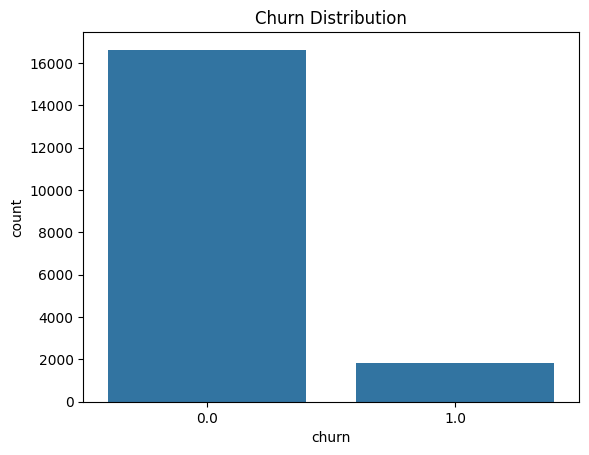

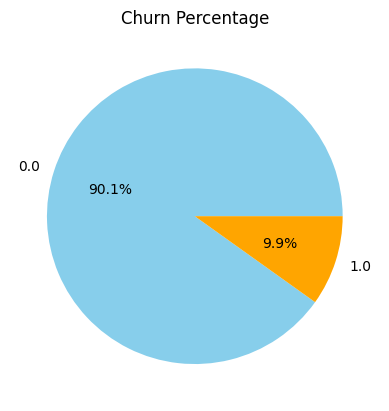

In [7]:
#Q2. Analyze the target variable (Churn): class distribution, percentage and visualize using Count Plot and Pie Chart.

print(df['churn'].value_counts())

print(df['churn'].value_counts(normalize=True)*100)

#count plot
sns.countplot(x= 'churn', data=df)
plt.title("Churn Distribution")
plt.show()

#pie chart
df['churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','orange']
)
plt.ylabel("")
plt.title("Churn Percentage")
plt.show()

In [8]:
# Q3. Generate descriptive statistics using describe(). Identify highest mean, highest standard deviation and low variance features.

stats = df.describe()
print(stats)
print()

print("Highest Mean Feature", stats.loc['mean'].idxmax())
print()

print("Highest Standard Deviation", stats.loc['std'].idxmax())
print()

print("Low Variance Features")

variance = df.var(numeric_only=True)

print(variance.sort_values().head())


                age  annual_income    dependents        tenure  \
count  18444.000000   17912.000000  18444.000000  18444.000000   
mean      44.789471   58982.729565      0.800152     22.513934   
std       14.515893   37109.598894      0.893000     20.078471   
min       18.000000   20000.000000      0.000000      1.000000   
25%       34.000000   32683.582500      0.000000      7.000000   
50%       45.000000   48992.860000      1.000000     16.000000   
75%       55.000000   73865.472500      1.000000     33.000000   
max       90.000000  250000.000000      5.000000     72.000000   

       senior_citizen  monthlycharges  totalcharges  num_services  \
count    18444.000000    18444.000000  18444.000000  18444.000000   
mean         0.199306       86.637647   1855.161355      2.569453   
std          0.399489       26.901960   1819.134381      1.406949   
min          0.000000       20.000000     20.750000      1.000000   
25%          0.000000       70.880000    504.237500      1.0

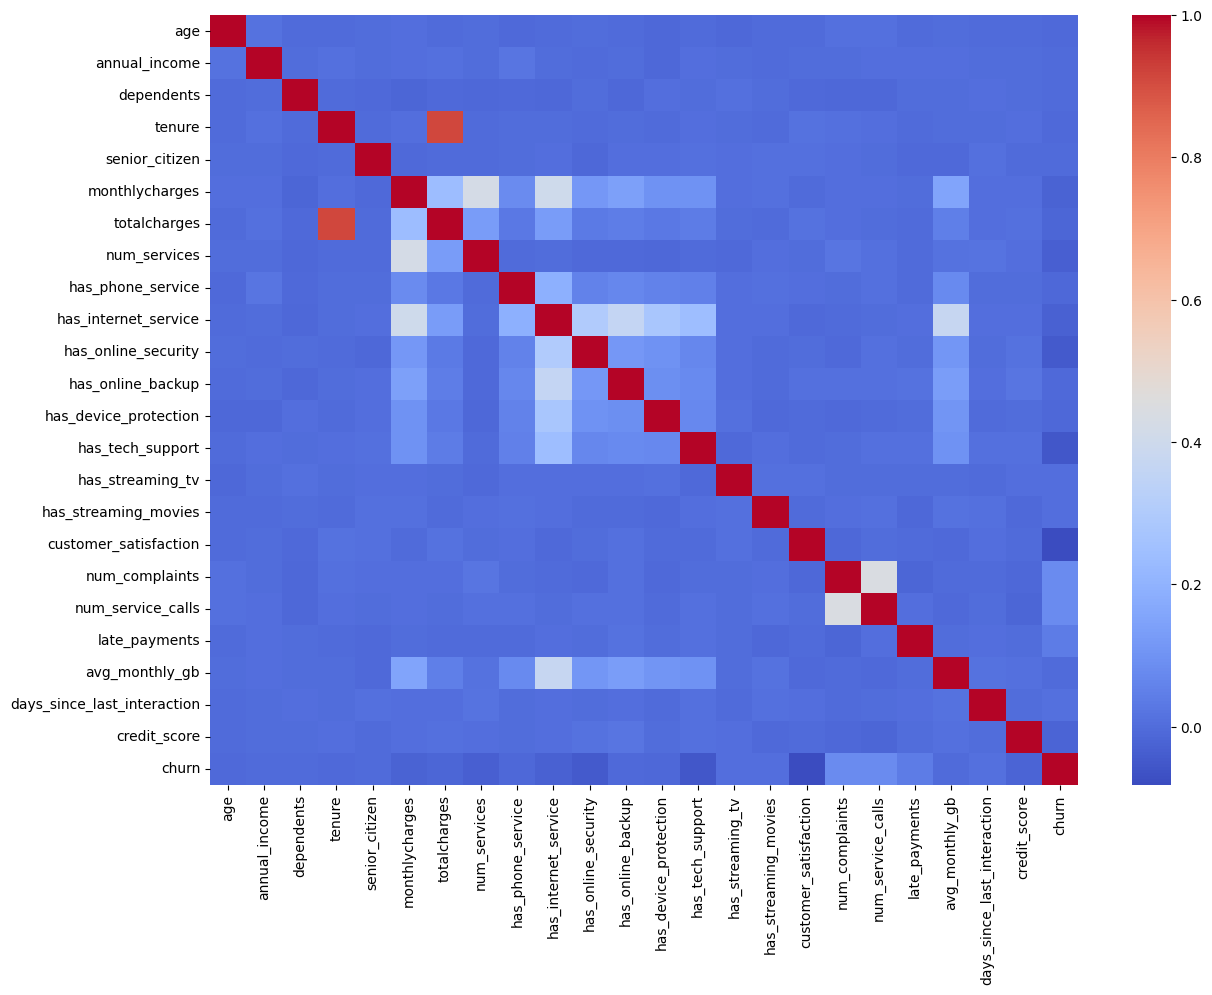

In [9]:
#Q4. Create a correlation heatmap.

plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)
sns.heatmap(corr,cmap='coolwarm')

plt.show()



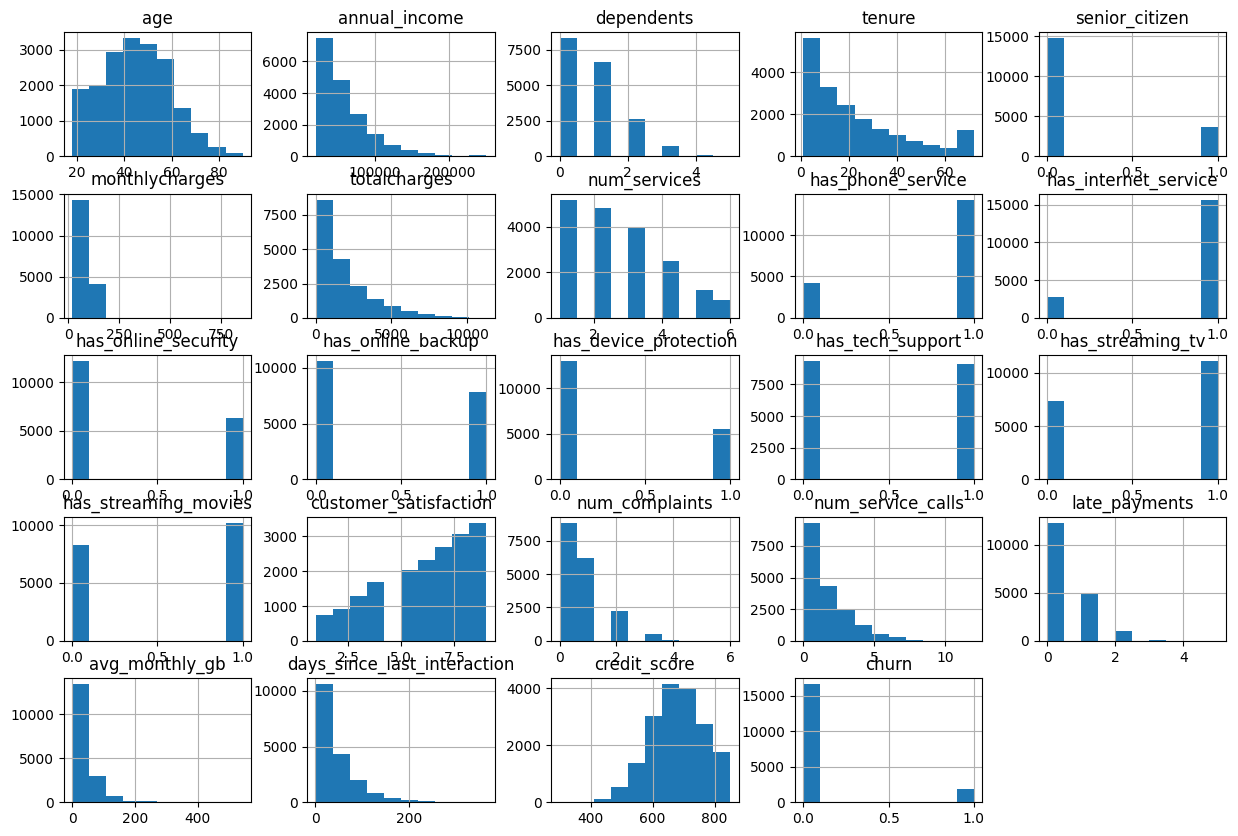

In [10]:
#Q5. Create at least five meaningful visualizations and write your observations.

#histogram
df.hist(figsize=(15,10))
plt.show()

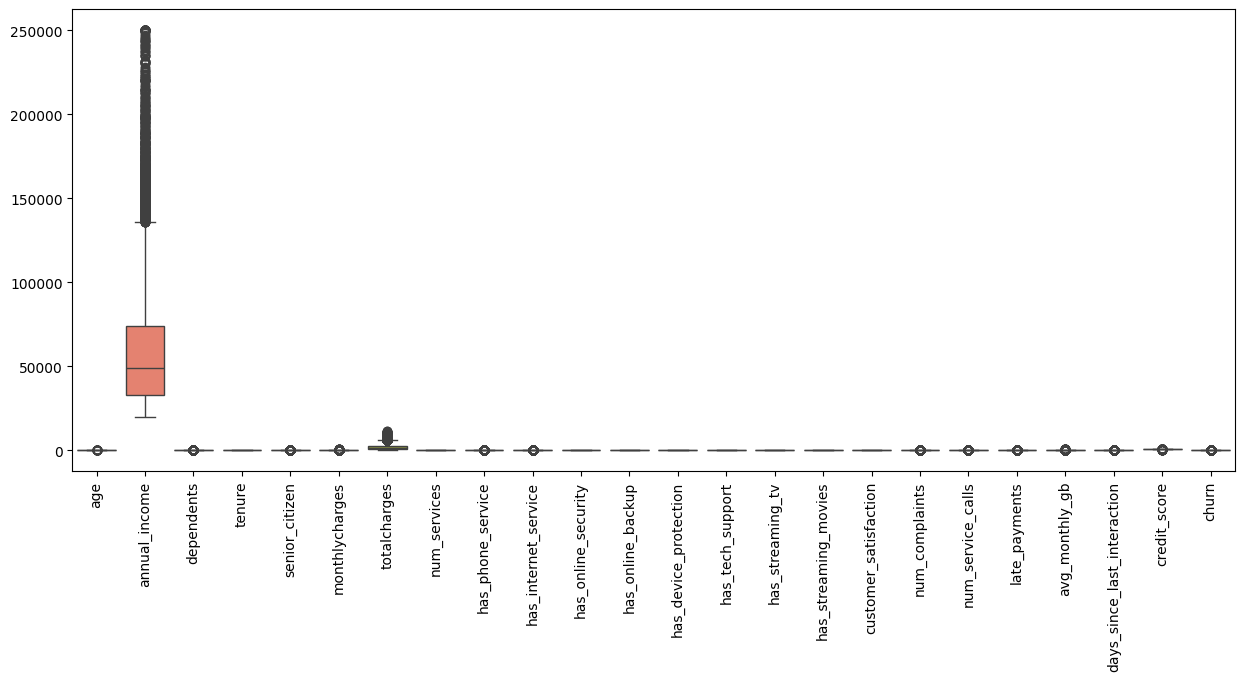

In [11]:
# box plot chart

plt.figure(figsize=(15,6))

sns.boxplot(data=df.select_dtypes(include='number'))

plt.xticks(rotation=90)

plt.show()

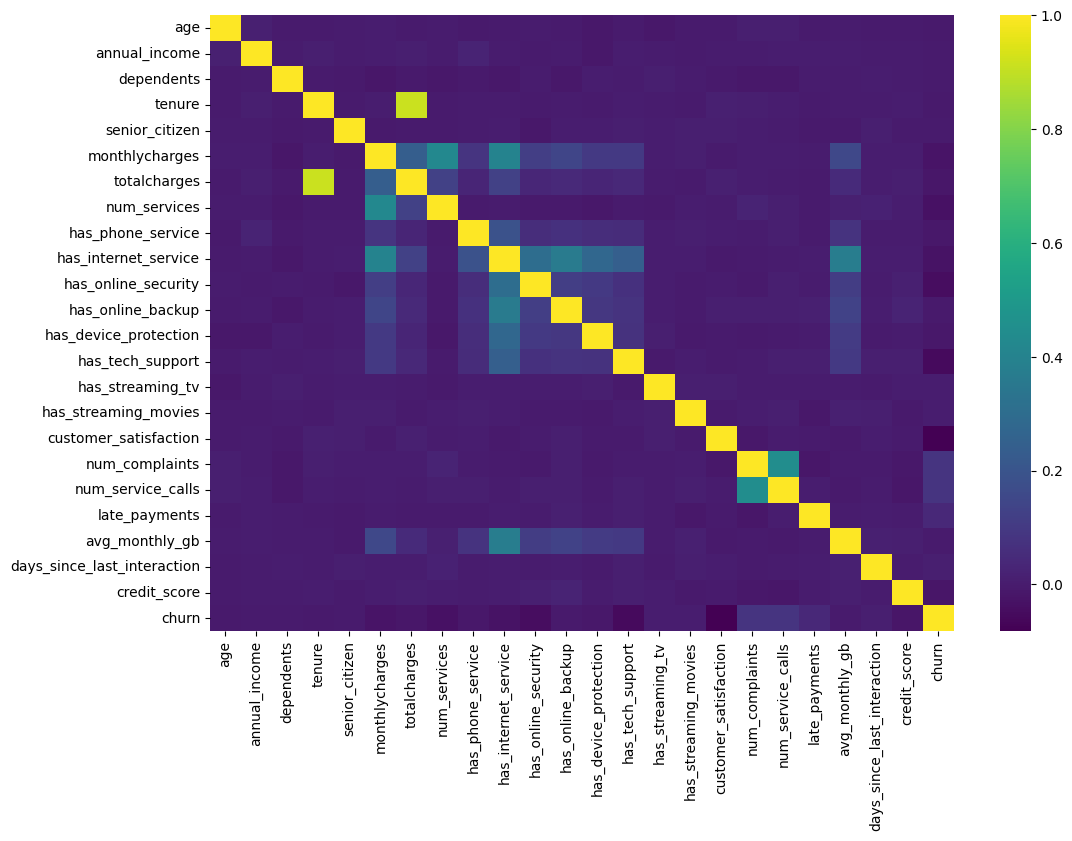

In [12]:
# correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(corr,cmap='viridis')

plt.show()

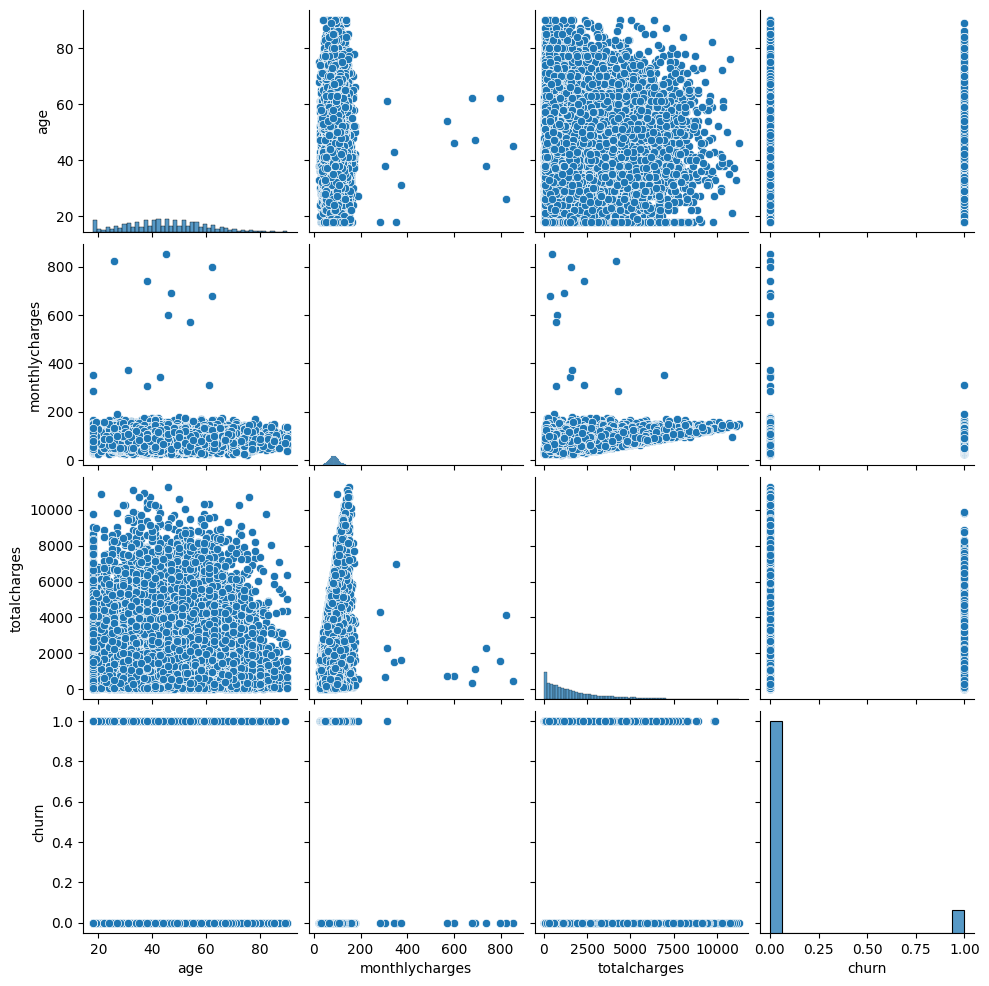

In [13]:
# pairplot
sns.pairplot(df[['age','monthlycharges','totalcharges','churn']])

plt.show()

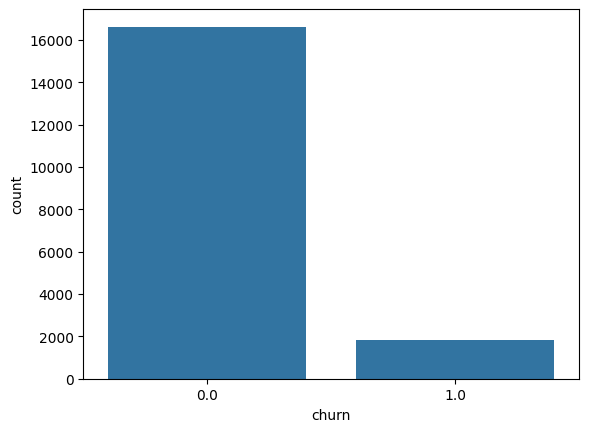

In [14]:
sns.countplot(x='churn',data=df)

plt.show()

Section 2: Data Preprocessing

In [15]:
# Q6. Handle missing values, duplicate records and outliers.


# -----------------------------
# 1. Check Missing Values
# -----------------------------
print("Missing Values Before Handling:\n")
print(df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        # Fill categorical columns with mode
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        # Fill numerical columns with median
        df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values After Handling:\n")
print(df.isnull().sum())

# -----------------------------
# 2. Remove Duplicate Records
# -----------------------------
print("\nDuplicate Records:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

# -----------------------------
# 3. Handle Outliers (IQR Method)
# -----------------------------
numeric_columns = df.select_dtypes(include=np.number).columns

# Exclude target column if it is numeric
numeric_columns = [col for col in numeric_columns if col != 'churn']

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset Shape After Removing Outliers:", df.shape)

Missing Values Before Handling:

customer_id                      0
signup_date                      0
age                              1
gender                           1
annual_income                  533
education                        1
marital_status                   1
dependents                       1
tenure                           1
contract                         1
payment_method                   1
paperless_billing                1
senior_citizen                   1
monthlycharges                   1
totalcharges                     1
num_services                     1
has_phone_service                1
has_internet_service             1
has_online_security              1
has_online_backup                1
has_device_protection            1
has_tech_support                 1
has_streaming_tv                 1
has_streaming_movies             1
customer_satisfaction          349
num_complaints                 602
num_service_calls                1
late_payments         

/tmp/ipykernel_967/2036845745.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_967/2036845745.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [16]:
# Q7. Encode categorical features using appropriate encoding techniques.

from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns)

# Apply Label Encoding
label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoding Completed Successfully.")

# Check data types after encoding
print(df.dtypes)

Categorical Columns:
Index(['customer_id', 'signup_date', 'gender', 'education', 'marital_status',
       'contract', 'payment_method', 'paperless_billing'],
      dtype='object')

Encoding Completed Successfully.
customer_id                      int64
signup_date                      int64
age                            float64
gender                           int64
annual_income                  float64
education                        int64
marital_status                   int64
dependents                     float64
tenure                         float64
contract                         int64
payment_method                   int64
paperless_billing                int64
senior_citizen                 float64
monthlycharges                 float64
totalcharges                   float64
num_services                   float64
has_phone_service              float64
has_internet_service           float64
has_online_security            float64
has_online_backup              float64
has_de

In [17]:
# Q8. Split the dataset into 80% training and 20% testing (random_state=42).

from sklearn.model_selection import train_test_split


X = df.drop('churn', axis=1)
y = df['churn']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print( )
# Display the shape of the datasets
print("Training Features Shape:", X_train.shape)
print()
print("Testing Features Shape:", X_test.shape)
print()
print("Training Target Shape:", y_train.shape)
print()
print("Testing Target Shape:", y_test.shape)


Training Features Shape: (5156, 31)

Testing Features Shape: (1290, 31)

Training Target Shape: (5156,)

Testing Target Shape: (1290,)


In [18]:
# Q9. Apply StandardScaler and explain why feature scaling is important for ANN.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Applied Successfully!")

Feature Scaling Applied Successfully!


Section 3: ANN Model Development

In [19]:
# Q10. Build an ANN with Input Layer, Dense(128, ReLU), Dense(64, ReLU), Dense(32, ReLU) and Output Layer (Sigmoid). Draw and explain the architecture.

model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(
    units=128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Hidden Layer 2
model.add(Dense(
    units=64,
    activation='relu'
))

# Hidden Layer 3
model.add(Dense(
    units=32,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,465 (56.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Q11. Train the model using Adam Optimizer, Binary Crossentropy Loss, Epochs=50 and Batch Size=32. Plot Accuracy and Loss curves.

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
#train the model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9047 - loss: 0.3184 - val_accuracy: 0.9225 - val_loss: 0.2657
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9144 - loss: 0.2790 - val_accuracy: 0.9225 - val_loss: 0.2609
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9144 - loss: 0.2723 - val_accuracy: 0.9225 - val_loss: 0.2611
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9144 - loss: 0.2617 - val_accuracy: 0.9225 - val_loss: 0.2687
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9144 - loss: 0.2515 - val_accuracy: 0.9225 - val_loss: 0.2667
Epoch 6/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9154 - loss: 0.2371 - val_accuracy: 0.9205 - val_loss: 0.2712
Epoch 7/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9210 - loss: 0.2189 - val_accuracy: 0.9215 - val_loss: 0.2787
Epoch 8/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9273 - loss: 0.1965 - val_accuracy: 0

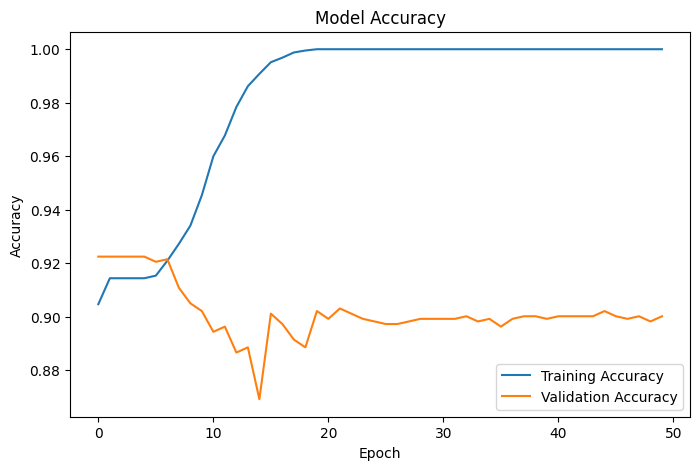

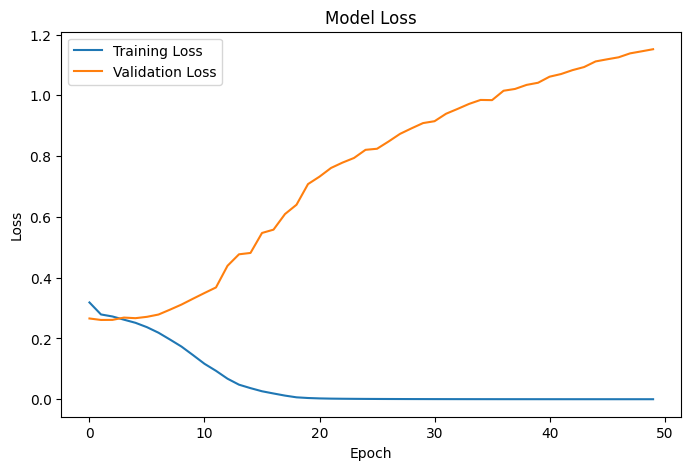

In [22]:
#Plot Accuracy and Loss Curves

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Section 4: Model Evaluation

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy      : 0.8868
Precision     : 0.1935
Recall        : 0.1111
F1-Score      : 0.1412
ROC-AUC Score : 0.5948

Confusion Matrix:

[[1132   50]
 [  96   12]]


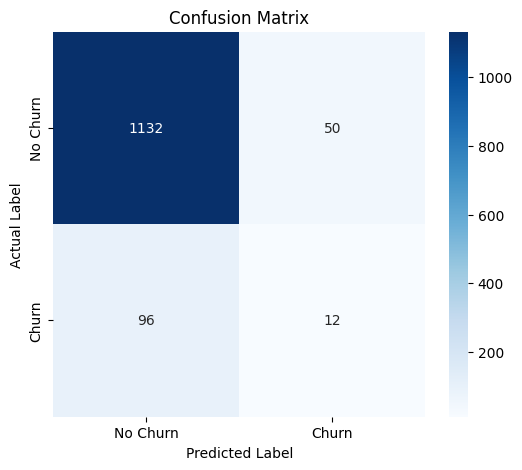

In [23]:
# Q12. Evaluate the model using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score and Confusion Matrix.


# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities into binary class labels
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Print Results
print("Accuracy      :", round(accuracy, 4))
print("Precision     :", round(precision, 4))
print("Recall        :", round(recall, 4))
print("F1-Score      :", round(f1, 4))
print("ROC-AUC Score :", round(roc_auc, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [24]:
#Q13. Generate the Classification Report and interpret the results.

from sklearn.metrics import classification_report

# Convert class report to DataFrame
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision    recall  f1-score      support
0.0            0.921824  0.957699  0.939419  1182.000000
1.0            0.193548  0.111111  0.141176   108.000000
accuracy       0.886822  0.886822  0.886822     0.886822
macro avg      0.557686  0.534405  0.540298  1290.000000
weighted avg   0.860852  0.886822  0.872589  1290.000000


Section 5: Model Analysis

In [25]:
# Q14. Explain Forward Propagation, Backpropagation, ReLU, Sigmoid, Adam Optimizer and Binary Crossentropy.

#1. Forward Propagation

# Forward propagation is the process of passing input data through the neural network to generate predictions. Each neuron computes weighted inputs, adds a bias, and applies an activation function. The output is then passed to the next layer until the final prediction is obtained.

#2. Backpropagation

# Backpropagation is the learning process of an ANN. It calculates the prediction error and updates the network's weights and biases using gradient descent to minimize the loss and improve model accuracy.

# 3. ReLU (Rectified Linear Unit)

# ReLU is an activation function used in hidden layers. It outputs the input value if it is positive; otherwise, it outputs zero. ReLU speeds up training and helps overcome the vanishing gradient problem.

#4. Sigmoid

# The Sigmoid activation function converts the output into a value between 0 and 1, representing the probability of a class. It is commonly used in the output layer for binary classification problems like customer churn prediction.

#5. Adam Optimizer

# Adam (Adaptive Moment Estimation) is an optimization algorithm that updates the network weights efficiently using adaptive learning rates. It converges faster and provides better performance than traditional gradient descent methods.

#6. Binary Crossentropy

# Binary Crossentropy is the loss function used for binary classification. It measures the difference between the predicted probabilities and the actual class labels. Lower loss values indicate better model performance.

In [26]:
# Q15. Suggest five techniques to improve the ANN model performance.

#-------------------------------------------------------------------------------
#Technique to improve the model performance:-

#1 Hyperparameter Tuning: Optimize the learning rate, batch size, number of epochs, and number of neurons to improve model accuracy.

#2 Feature Engineering: Select relevant features and remove unnecessary or highly corelated items/ features to improve learning.

#3 Apply Dropout and Batch Normalization: These techniques reduce overfitting and improve the model's generalization performance.

#4 Use Early Stopping: Stop training when the validation loss stops improving to prevent overfitting.

#5 Increase Training Data: Using more high-quality training data helps the ANN learn better patterns and improves prediction accuracy.

In [27]:
# Q16. Prepare a comparison table of all evaluation metrics and summarize the model performance.



import pandas as pd

comparison_table = pd.DataFrame({
    "Evaluation Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

# Round values to 4 decimal places
comparison_table["Value"] = comparison_table["Value"].round(4)

print(comparison_table)

  Evaluation Metric   Value
0          Accuracy  0.8868
1         Precision  0.1935
2            Recall  0.1111
3          F1-Score  0.1412
4     ROC-AUC Score  0.5948
